# Imports

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from Utils.utils import loadData, reseed_grid_picker
from sklearn.model_selection import train_test_split
import pandas as pd
import keras_tuner as kt
from tqdm import tqdm
import os

2026-09-25 16:59:39.048065: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-25 16:59:39.975318: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-25 16:59:42.918245: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Load Dataset

In [2]:
train_x, train_y, labels = loadData("train")
test_x, test_y, labels = loadData("test", labels)

# Initial CNN testing

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(64, 64, 3)),
    keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, 3, activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(128, 3, activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(256, 3, activation="relu"),
    keras.layers.GlobalAveragePooling2D(),

    keras.layers.Dropout(0.4),
    keras.layers.Dense(len(labels),"softmax")
])

optimizer = keras.optimizers.Adam(learning_rate=0.0005)
# optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.0)

model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 30, 30, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389,958 (1.49 MB)

 Trainable params: 389,958 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_x, train_y, epochs=15, validation_split=0.1, batch_size=64,verbose=1)

Epoch 1/15
198/198 - 6s - 31ms/step - accuracy: 0.5117 - loss: 1.7642 - val_accuracy: 0.6239 - val_loss: 0.9464
Epoch 2/15
198/198 - 2s - 8ms/step - accuracy: 0.6793 - loss: 0.8545 - val_accuracy: 0.7137 - val_loss: 0.7784
Epoch 3/15
198/198 - 2s - 8ms/step - accuracy: 0.7266 - loss: 0.7516 - val_accuracy: 0.7464 - val_loss: 0.7010
Epoch 4/15
198/198 - 2s - 8ms/step - accuracy: 0.7572 - loss: 0.6725 - val_accuracy: 0.7564 - val_loss: 0.6480
Epoch 5/15
198/198 - 2s - 8ms/step - accuracy: 0.7851 - loss: 0.6021 - val_accuracy: 0.8013 - val_loss: 0.5664
Epoch 6/15
198/198 - 2s - 8ms/step - accuracy: 0.8055 - loss: 0.5520 - val_accuracy: 0.8048 - val_loss: 0.5698
Epoch 7/15
198/198 - 2s - 8ms/step - accuracy: 0.8144 - loss: 0.5239 - val_accuracy: 0.8226 - val_loss: 0.5164
Epoch 8/15
198/198 - 2s - 8ms/step - accuracy: 0.8305 - loss: 0.4731 - val_accuracy: 0.7963 - val_loss: 0.5749
Epoch 9/15
198/198 - 2s - 8ms/step - accuracy: 0.8422 - loss: 0.4427 - val_accuracy: 0.8226 - val_loss: 0.4915


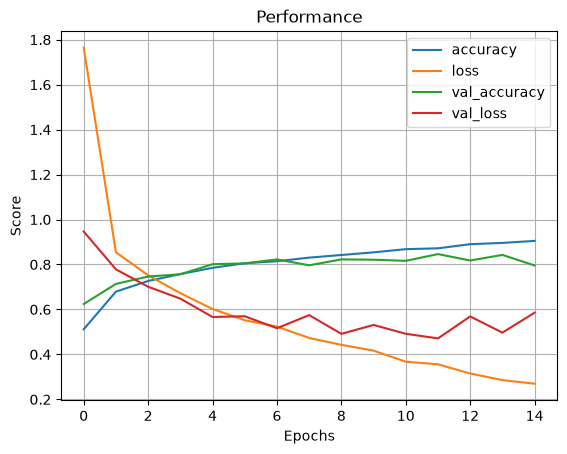

In [23]:
for key in history.history.keys():
    plt.plot(history.history[key], label=key)
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.title("Performance")
plt.grid()
plt.legend()
plt.show()

Model achieved 90.49% training accuracy and 79.56% test accuracy.
More hyperparameters tuning needed

## Hyperparameter tuning

In [ ]:
def build_model(hp):
    model = keras.Sequential()

    hp_learn_rate = hp.Float("learning_rate", min_value=1e-5, max_value=1e-2,sampling='log')
    hp_drop_rate = hp.Float("drop_rate", min_value=0, max_value=1, step=0.1)

    model.add(keras.Input(shape=(64, 64, 3)))
    model.add(keras.layers.Conv2D(32, 3, activation="relu", padding="same"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(64, 3, activation="relu"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(128, 3, activation="relu"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(256, 3, activation="relu"))
    model.add(keras.layers.GlobalAveragePooling2D())

    model.add(keras.layers.Dropout(hp_drop_rate))
    model.add(keras.layers.Dense(len(labels),"softmax"))

    metrics = hp.Choice("metrics", values=["accuracy", "categorical_accuracy"])

    optimizer = keras.optimizers.Adam(learning_rate=hp_learn_rate)

    model.compile(optimizer, loss="sparse_categorical_crossentropy", metrics=[metrics])
    
    return model

In [4]:
tuner = kt.GridSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    directory="CNN_search",
    project_name="Model_selection2",
    overwrite=False,
)

reseed_grid_picker(tuner)  # Workaround from the previous answer

x_train, x_val, y_train, y_val = train_test_split(train_x, train_y, test_size=0.1, random_state=42, shuffle=False)

tuner.search(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_val, y_val),
)

Reloading Tuner from CNN_search/Model_selection2/tuner0.json


I0000 00:00:1790141765.226628  875123 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Choosing the top 10 models for further tuning

In [5]:
best_params = tuner.get_best_hyperparameters(10)
best_models = tuner.get_best_models(10)

/home/nilesh/miniconda3/envs/tf220/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(store)


In [ ]:
params_df = []
for i, param in enumerate(best_params):
    loss, accuracy = best_models[i].evaluate(test_x, test_y, verbose=0)

    params_df.append({"name": f"model{i}",
                      "model": best_models[i] ,
                      "param": param,
                      "loss": loss,
                      "accuracy": accuracy,
                      "learning_rate": param["learning_rate"],
                      "drop_rate" : param["drop_rate"],
                      "metric": param["metrics"]})

params_df = pd.DataFrame(params_df).sort_values("accuracy", ascending=False, ignore_index=True)

params_df

,name,model,param,loss,accuracy,learning_rate,drop_rate,metric
0,model5,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.524637,0.810333,0.000447,0.1,accuracy
1,model0,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.568092,0.808667,0.000447,0.6,accuracy
2,model7,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.554908,0.806333,0.000447,0.4,accuracy
3,model1,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.561818,0.806000,0.000891,0.4,accuracy
4,model2,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.583540,0.804333,0.000891,0.0,accuracy
5,model8,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.586864,0.802667,0.000224,0.0,accuracy
6,model9,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.577724,0.801000,0.000447,0.3,accuracy
7,model3,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.581876,0.794000,0.000447,0.7,accuracy
8,model4,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.589521,0.791667,0.000891,0.5,accuracy
9,model6,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.604857,0.787333,0.000891,0.7,accuracy


Top 6 models are chosen to fine tune

In [76]:
models = []
histories = []
top = 6
progress = tqdm(None, "Model", top, initial=0)
for i, params in params_df.iterrows():
    models.append(build_model(params["param"]))
    histories.append(models[-1].fit(train_x, train_y, epochs=15, validation_split=0.1, batch_size=64,verbose=0))
    if i >= top:
        break
    progress.update()

Model: 100%|██████████| 6/6 [02:44<00:00, 27.20s/it]

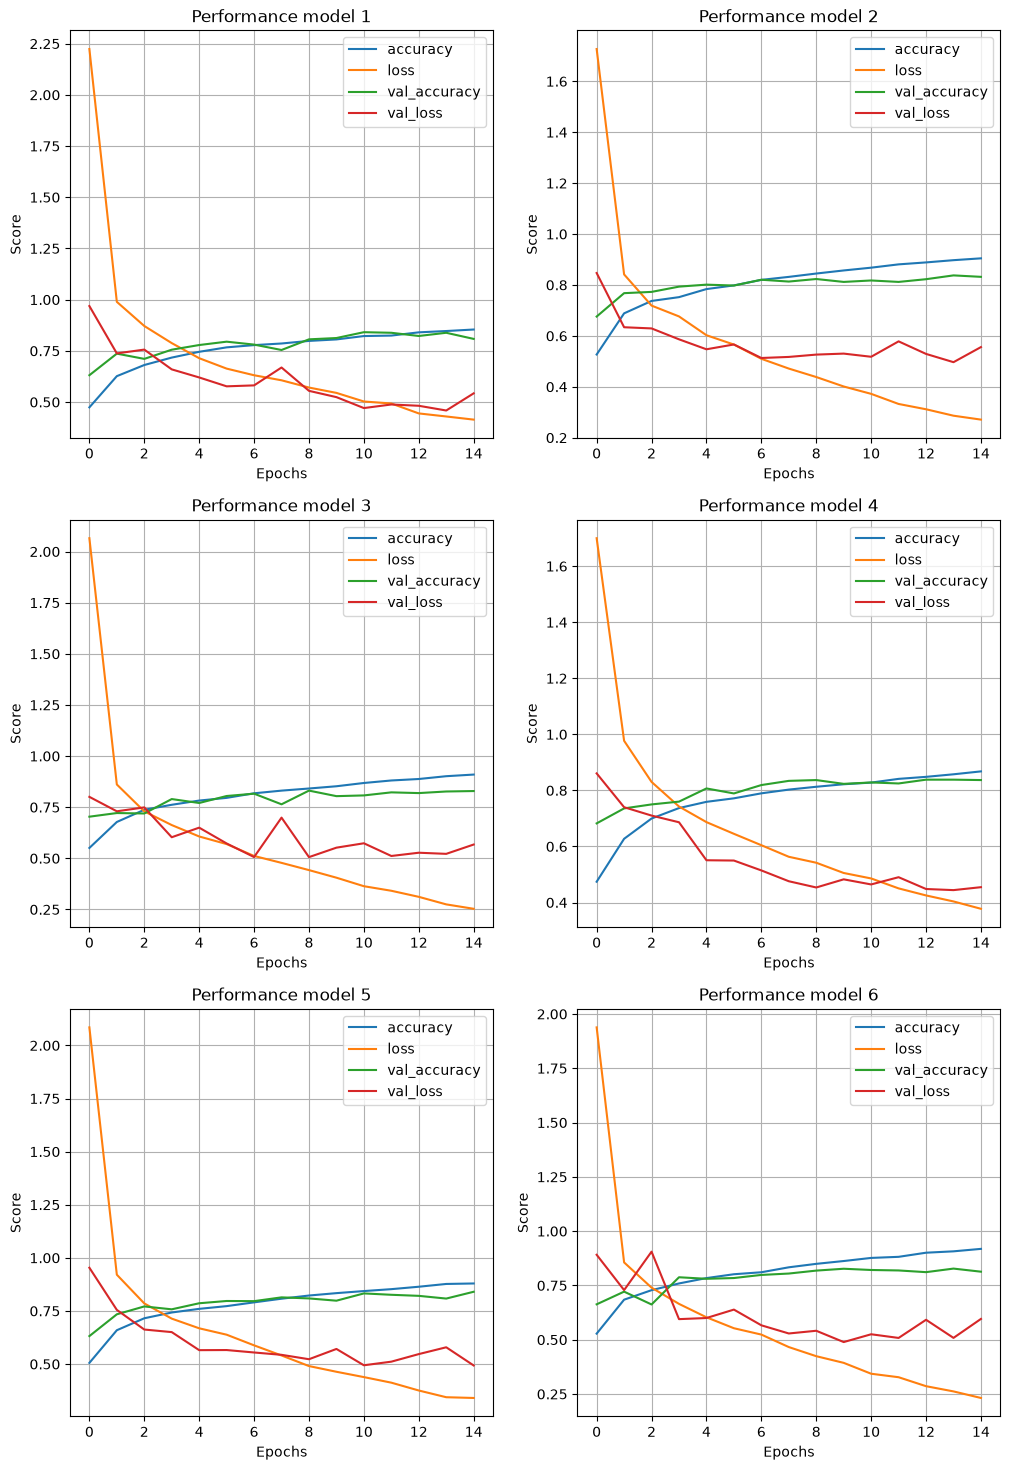

In [17]:
plt.figure(figsize=(12,18))
for i, history in enumerate(histories):
    plt.subplot(3,2,i+1)
    for key in history.history.keys():
        plt.plot(history.history[key], label=key)
    plt.xlabel("Epochs")
    plt.ylabel("Score")
    plt.title(f"Performance model {i+1}")
    plt.grid()
    plt.legend()

plt.show()

In [21]:
for i, model in enumerate(best_models[:top]):
    model.save(os.path.join(os.curdir, "CNN_models", "best_models", f"model{i}.keras"), overwrite=True)

# With Dense layers

In [3]:
def build_model(hp):
    model = keras.Sequential()
    hp_drop_rate = hp.Choice("drop_rate", values=[0.0, 0.4, 0.7, 0.1, 0.6])

    model.add(keras.Input(shape=(64, 64, 3)))
    model.add(keras.layers.Conv2D(32, 3, activation="relu", padding="same"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(64, 3, activation="relu"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(128, 3, activation="relu"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(256, 3, activation="relu"))
    model.add(keras.layers.GlobalAveragePooling2D())

    hp_layers = hp.Int("layer", min_value=0, max_value=3, step=1)
    units = {}
    dropouts = {}

    for i in range(1, 4):
        with hp.conditional_scope("layer", list(range(i, 4))):
            units[i] = hp.Choice(
                f"unit{i}",
                values=[32, 64, 128, 256, 512],
            )
            dropouts[i] = hp.Float(
                f"drop{i}",
                min_value=0.1,
                max_value=0.9,
                step=0.1,
            )

    for i in range(hp_layers, 0, -1):
        model.add(keras.layers.Dense(units[i], activation="relu"))
        model.add(keras.layers.Dropout(dropouts[i]))

    model.add(keras.layers.Dropout(hp_drop_rate))

    model.add(keras.layers.Dense(len(labels),"softmax"))

    optimizer = keras.optimizers.Adam(learning_rate=0.000447)

    model.compile(optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    return model

In [ ]:
tuner = kt.GridSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    directory="CNN_search",
    project_name="Model_selection3",
    overwrite=False,
)

reseed_grid_picker(tuner)  # Workaround from the previous answer

x_train, x_val, y_train, y_val = train_test_split(train_x, train_y, test_size=0.1, random_state=42, shuffle=False)

tuner.search(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_val, y_val),
)

Trial 1521 Complete [00h 00m 17s]
val_accuracy: 0.7827635407447815

Best val_accuracy So Far: 0.8311966061592102
Total elapsed time: 2d 03h 55m 16s

Search: Running Trial #1522

Value             |Best Value So Far |Hyperparameter
0                 |0                 |drop_rate
2                 |2                 |layer
0.6               |0.4               |drop1
256               |256               |unit1
0.9               |0.2               |drop2
256               |512               |unit2

Epoch 1/5
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2653 - loss: 2.0468

# With BatchNormalize

In [ ]:
def build_model(hp):
    model = keras.Sequential()

    hp_learn_rate = hp.Float("learning_rate", min_value=1e-5, max_value=1e-2,sampling='log')
    hp_drop_rate = hp.Float("drop_rate", min_value=0, max_value=1, step=0.1)

    

    model.add(keras.Input(shape=(64, 64, 3)))
    model.add(keras.layers.Conv2D(32, 3, activation="relu", padding="same"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(64, 3, activation="relu"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(128, 3, activation="relu"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(256, 3, activation="relu"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.GlobalAveragePooling2D())

    model.add(keras.layers.Dropout(hp_drop_rate))
    model.add(keras.layers.Dense(len(labels),"softmax"))

    optimizer = keras.optimizers.Adam(learning_rate=hp_learn_rate)

    model.compile(optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    return model

In [ ]:
tuner = kt.GridSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    directory="CNN_search",
    project_name="Model_selection4",
    overwrite=False,
)

reseed_grid_picker(tuner)  # Workaround from the previous answer

x_train, x_val, y_train, y_val = train_test_split(train_x, train_y, test_size=0.1, random_state=42, shuffle=False)

tuner.search(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_val, y_val),
)

In [ ]:
best_params = tuner.get_best_hyperparameters(10)
best_models = tuner.get_best_models(10)

In [ ]:
params_df = []
for i, param in enumerate(best_params):
    loss, accuracy = best_models[i].evaluate(test_x, test_y, verbose=0)

    params_df.append({"name": f"model{i}",
                      "model": best_models[i] ,
                      "param": param,
                      "loss": loss,
                      "accuracy": accuracy,
                      "learning_rate": param["learning_rate"],
                      "drop_rate" : param["drop_rate"]})

params_df = pd.DataFrame(params_df).sort_values("accuracy", ascending=False, ignore_index=True)

params_df

In [ ]:
models = []
histories = []
top = 6
progress = tqdm(None, "Model", top, initial=0)
for i, params in params_df.iterrows():
    models.append(build_model(params["param"]))
    histories.append(models[-1].fit(train_x, train_y, epochs=15, validation_split=0.1, batch_size=64,verbose=0))
    if i >= top:
        break
    progress.update()

In [ ]:
plt.figure(figsize=(12,18))
for i, history in enumerate(histories):
    plt.subplot(3,2,i+1)
    for key in history.history.keys():
        plt.plot(history.history[key], label=key)
    plt.xlabel("Epochs")
    plt.ylabel("Score")
    plt.title(f"Performance model {i+1}")
    plt.grid()
    plt.legend()

plt.show()

In [ ]:
for i, model in enumerate(best_models[:top]):
    model.save(os.path.join(os.curdir, "Best_CNN_models", "CNN_BatchNormalize", f"model{i}.keras"), overwrite=True)